<a href="https://colab.research.google.com/github/TienNguyen0712/sentiment-analysis/blob/main/imdb/sentiment_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📁 Data Overview (Giới thiệu dữ liệu)**

Notebook này được viết mục tiêu nhằm áp dụng những kỹ thuật trong NLP:
- Phân tích cảm xúc dựa trên bộ dữ liệu IMDB (Giới thiệu phim)
- Dự đoán nhãn của một review phim

**Việc dự đoán cảm xúc khi thực hiện review phim**

Doanh nghiệp xác định tệp khách hàng, các bình luận đánh giá mang tính tích cực hay tiêu cực. Nếu tích cực thì phát triển thế mạnh còn tiêu cực thì tiếp thu và sửa đổi. Bên cạnh đó có thể sử sụng bộ dữ liệu để xây dựng một hệ thống gợi ý trong tương lai

- *Input:* đoạn text (review phim)
- *Output:*
  - `0`: Tiêu cực
  - `1`: Tích cực

**Người có thể sử dụng**

- Nhà quản trị khách hàng
- Khoa học dữ liệu
- Kỹ sư AI và ML

---

**Về bộ dữ liệu**

Có sẵn trong thư viện `datasets` chia thành 3 tập:
- train: 25000 dòng và 2 cột
- test: 25000 dòng và 2 cột
- val: 50000 dòng và 2 cột

**Đặc trưng**

- `text:` chứa nội dung văn bản
- `label:` chưa nhãn của các nội dung đó (0: negative, 1: positive)



In [1]:
from datasets import load_dataset

df = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
df # Thông tin dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [3]:
train_df = df['train']
test_df = df['test']
val_df = df['unsupervised']

# **🧩 Data Prepocessing (Chuẩn bị dữ liệu)**

Xem 5 dòng đầu của dataset

In [4]:
for i in range(5):
  print(train_df[i])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Thực hiên bước tiền xử lý dữ liệu
- string: thực hiện các thao tác với string
- re: Dùng để loại bỏ các ký tự HTML, URL, Số
- nltk: Nhằm loại bỏ stopword trong câu

In [5]:
import re
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. lowercase chuyển tất cả thành chữ thường
    text = text.lower()
    # 2. bỏ HTML tags
    text = re.sub(r"<.*?>", "", text)
    # 3. bỏ URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # 4. bỏ số
    text = re.sub(r"\d+", "", text)
    # 5. bỏ dấu câu
    text = text.translate(str.maketrans("", "", string.punctuation))
    # 6. bỏ khoảng trắng thừa
    text = text.strip()
    # 7. tokenize + remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    # 8. join lại
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
train_df = train_df.map(lambda x: {"text": clean_text(x["text"])})
test_df = test_df.map(lambda x: {"text": clean_text(x["text"])})

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


# **🎯 EDA Objective (Mục tiêu Khám phá dữ liệu)**

Mục tiêu việc khám phá dữ liệu này nhằm:
- Xác định số lượng label có trong tập train và test
- Các từ phổ biến có độ dài giao động là bao nhiêu

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
%matplotlib inline


import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'
plt.rcParams["figure.facecolor"] = "#fafafa"
plt.rcParams["axes.facecolor"] = "#fafafa"

# 📈 **Target Variable Distribution - Label (Phân bố biến mục tiêu - Label)**

In [8]:
labels = train_df["label"]
print(Counter(labels)) # Đếm số lượng nhãn có trong dataset

Counter({0: 12500, 1: 12500})


# **🔍 Features Distribution (Các đặc trưng khác)**

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

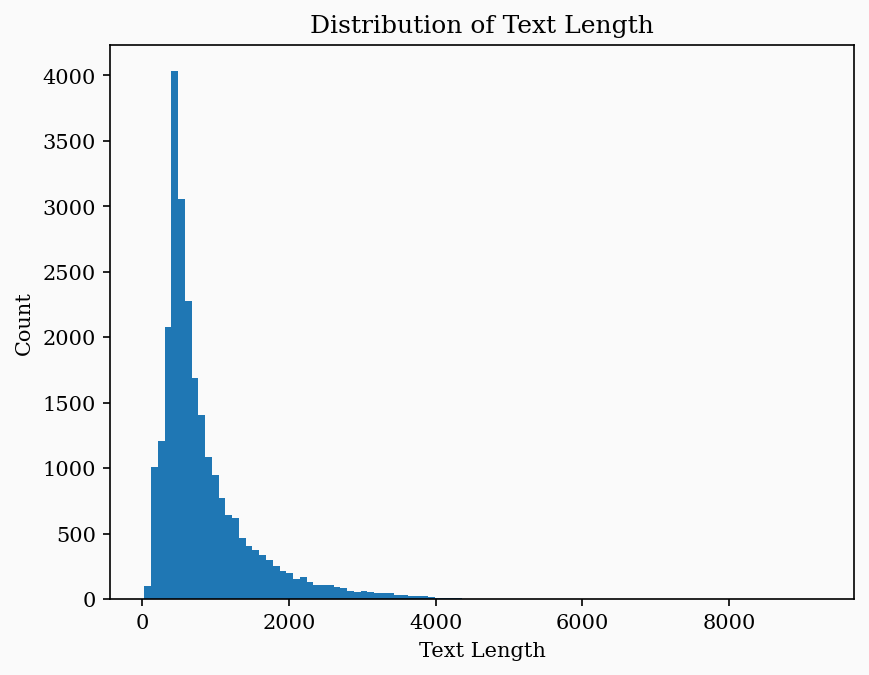

In [9]:
train_df = train_df.map(lambda x: {"length": len(x['text'])})

plt.hist(train_df["length"], bins=100)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title("Distribution of Text Length") # Phân bố độ dài của text
plt.show()

**Nhận xét**

Đa số chiều dài của các từ nằm trong khoảng từ 0 đến 6000 từ
- Dễ thấy các câu có độ dài phổ biến nhất chính là giữa khaorng từ trên 0 đến 2000 từ
- Ta có thể cân nhắc lấy các câu có số từ dài trở đi do chúng có đóng góp nhiều trong mô hình sau này

In [10]:
all_words = " ".join(train_df["text"]).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('movie', 41825), ('film', 37488), ('one', 25165), ('like', 19567), ('good', 14516), ('even', 12327), ('would', 12124), ('time', 11806), ('really', 11642), ('story', 11438), ('see', 11179), ('much', 9550), ('get', 9200), ('well', 9200), ('people', 8926), ('bad', 8903), ('also', 8899), ('great', 8849), ('first', 8689), ('dont', 8308)]


**Nhận xét**

Bên trên là số lần các từ được dếm xuất hiện trong bộ dữ liệu. Ta có thể thấy rằng
- Các từ `film` hay `movie` xuất hiện rất nhiều. Điều này là hiển nhiên khi dữ liệu này là về fim

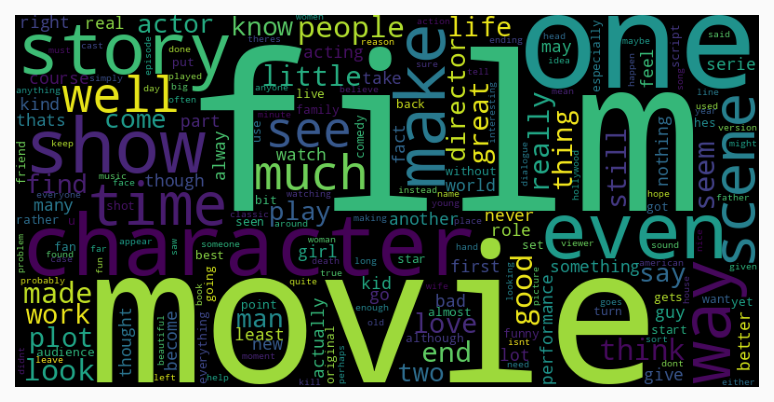

In [11]:
text = " ".join(train_df["text"])

wordcloud = WordCloud(width=800, height=400).generate(text) # Các từ được nhắc đến nhiều trong bộ dữ liệu train

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

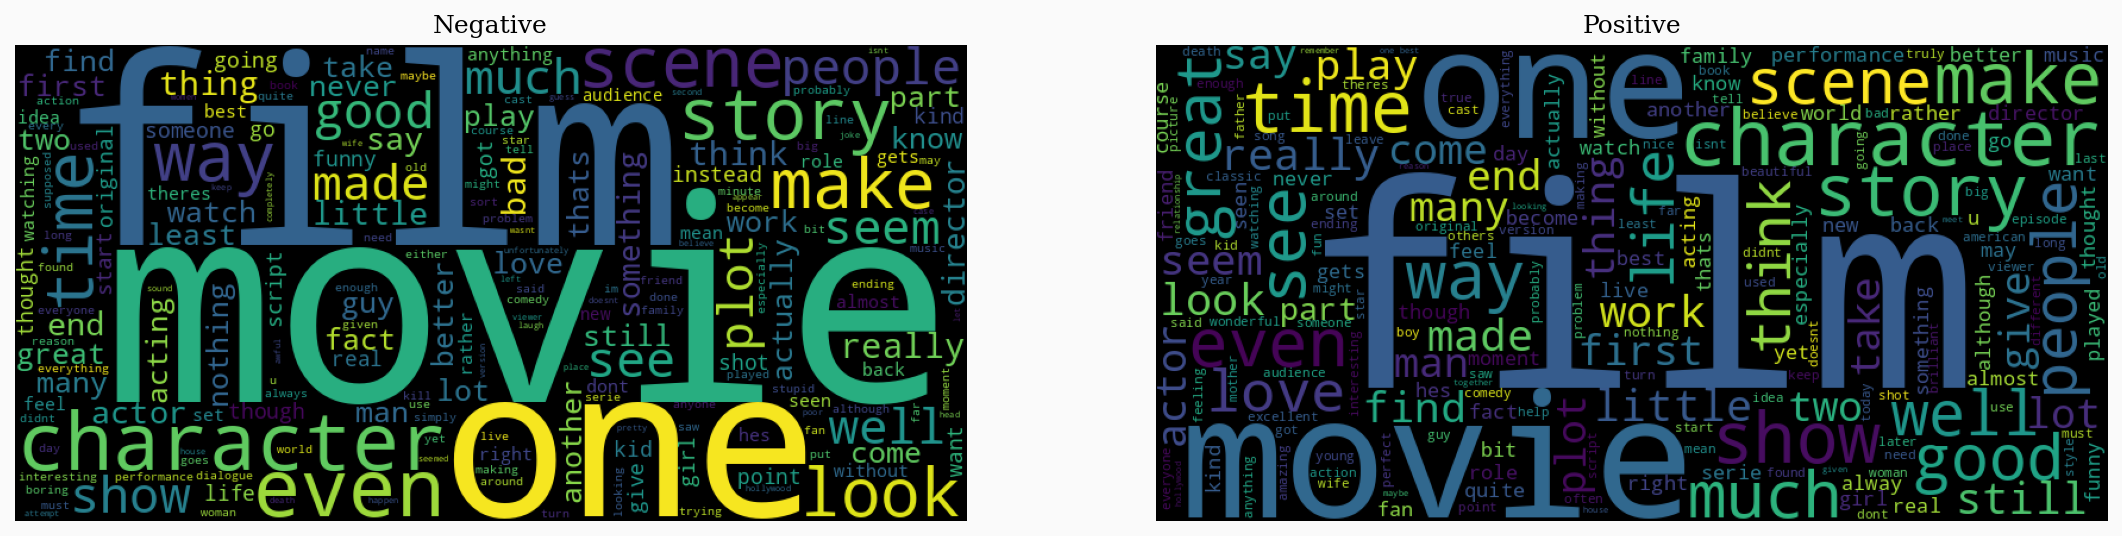

In [12]:
# So sánh giữa negative và positive

negative_dataset = train_df.filter(lambda x: x["label"] == 0) # Tách thành các bảng có label là 0 và 1
positive_dataset = train_df.filter(lambda x: x["label"] == 1)

negative_text = " ".join(negative_dataset["text"])
positive_text = " ".join(positive_dataset["text"])


fig = plt.figure(figsize=(18,15))
gs = fig.add_gridspec(1, 2)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

ax0.imshow(WordCloud(width=800, height=400).generate(negative_text))
ax0.set_title("Negative")
ax0.axis("off")
ax1.imshow(WordCloud(width=800, height=400).generate(positive_text))
ax1.set_title("Positive")
ax1.axis("off")
plt.show()

**Nhận xét**

WordCloud của hai bảng tích cực và tiêu cực không khác gì nhau là mấy do chúng cùng đề cập nhiều đến phim, diễn viên và bối cảnh thười gian xem phim

In [13]:
train_df = train_df.remove_columns(["length"])

In [14]:
train_df['text'][0] # Xem qua dữ liệu cuối cùng

'rented curiousyellow video store controversy surrounded first released also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular wants focus attentions making sort documentary average swede thought certain political issues vietnam war race issues united states asking politicians ordinary denizens stockholm opinions politics sex drama teacher classmates married menwhat kills curiousyellow years ago considered pornographic really sex nudity scenes far even shot like cheaply made porno countrymen mind find shocking reality sex nudity major staple swedish cinema even ingmar bergman arguably answer good old boy john ford sex scenes filmsi commend filmmakers fact sex shown film shown artistic purposes rather shock people make money shown pornographic theaters america curiousyellow good film anyone wanting study meat potatoes p

# ✅ **EDA Summary (Tóm tắt Khám phá dữ liệu)**

**Về bộ dữ liệu**
- Dữ liều này được láy từ các bình luận giới thiệu về phim gồm 2 nhãn tích cực (1) và tiêu cực (0)
- Đánh giá chung bộ dữ liệu cân bằng
- Không có dữ liệu thiếu hay trùng thích hợp để xây dựng các mô hình phía sau
- Dữ liệu khá bẩn: có stopword, có các tag HTML, có dấu câu, ... (Đã thực hiện làm sạch)

**Về đặc trưng**
- Phân bố đều ở cả hai nhãn `tích cực` và `tiêu cưc`
- Đồ dài của câu chủ yếu trong khoảng `0 - 2000` từ
- Các từ xuất hiện nhiều chủ yếu đề cập nhiều đến các chủ đề như phim, diễn viên, bối cảnh

# 🤖 **Feature Engineering (Text -> Vector)**

### **Thuật toán TF-IDF**

Là kỹ thuật thống kê dùng để đánh giá mức độ quan trọng của một từ trong một văn bản so với toàn bộ tập tài liệu

Ý tưởng cốt lõi chính là từ xuất hiện nhiều trong một tài liệu nhưng ít trong các tài liệu khác sẽ được gán là quan trọng và là đặc trưng cho tài liệu đó. Các từ phổ biến nằm trong "stopword" sẽ còa IDF thấp -> giảm trọng số từ nhiên

Gồm 2 thành phần chính:

- TF - tần suất xuất hiện của từ trong tài liệu
```
TF(t,d) = số lần từ t xuất hiện trong tài liệu d / tổng số từ trong d
```
- IDF - độ hiếm của từ trong toàn bộ tài liệu
```
IDF(t) = log(N/df(t))
trong đó N = tổng số tài liệu, df(t) số tài liệu chứa từ t
```



In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000, # Chỉ giữ 10000 từ quan trọng nhất
    ngram_range=(1,2), # Lấy từ 1 đến 2 từ
    min_df=5, # Bỏ từ xuất hiện trong ít hơn 5 tài liệu
    max_df=0.9 # Bỏ từ xuất hiện trong hơn 90% tài liệu
)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

### **Các thuật toán/kỹ thuật có thẻ thay thế TF-IDF**

- Cổ điển sơ khai
  - Bag of Words (BoW) - Đếm tần suất, bỏ thứ tự
  - BM26: Là nó nâng cao nhưng dùng trong search
- Nơ ron
  - Word2Vec / GloVe / FastText - Embedding, ngữ nghĩa gần nhau -> BERT / RoBERTa
  - Doc2Vec / LSA - Embedding cả đoạn văn / ma trận SVD -> Sentence Transformers



# **🏋️Model Training (Huấn luyện mô hình)**

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [32]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

# 📊 **Model Evaluation (Đánh giá mô hình)**

In [34]:
y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8854
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     12500
           1       0.88      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [35]:
y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.87016
              precision    recall  f1-score   support

           0       0.87      0.88      0.87     12500
           1       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



**Nhận xét**

Tối ưu nhất là mô hình Logistic Regression nó đã phân loại khá tối trong bộ dữ liệu này với đọ chính xác 89% với khả năng phát hiện nhãn tiêu cực là 89$ và trong những thứ mô hình dự đoán là tiêu cực thì có đến 89% là dự đoán đúng khá ấn tượng

# ❌ **Error Analysis (Phấn tích lỗi sai)**

In [41]:
test_dataset = df["test"].add_column("pred", y_pred)

wrong = test_dataset.filter(lambda x: x["pred"] != x["label"])

for i in range(5):
    print("TEXT:", wrong[i]["text"])
    print("TRUE:", wrong[i]["label"])
    print("PRED:", wrong[i]["pred"])
    print("-"*50)

TEXT: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!
TRUE: 0
PRED: 1
--------------------------------------------------
TEXT: Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' ar

**Nhận xét**

- Mô hình sẽ dễ mắc sai ở những câu dài, hay các câu có ý nghĩa trung lập và không có các từ ngữ nào chỉ đại diện cho một nhãn
- Một câu ban đầu chê phim nhưng về sau lại gợi ý các phim khác cũng như so sánh phim này nâng nên một chút sẽ khiến cho mô hình dễ bị nhầm lẫn hơn
- Các phim có phân tích chiều sâu cũng là mục đích cản trở cho mô hình dự đoán

In [57]:
# Demo test mô hình cho phân loại tích cực hoặc tiêu cực

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", vectorizer),
    ("model", lr)
])

def predict_sentiment(text):
    text = clean_text(text)
    pred = pipeline.predict([text])[0]
    return "Positive" if pred == 1 else "Negative"

def predict_with_proba(text):
    text = clean_text(text)

    proba = pipeline.predict_proba([text])[0]

    return {
        "label": "Positive" if proba[1] > 0.5 else "Negative",
        "confidence": float(max(proba))
    }

def demo_test():
    samples = [
        "This movie is amazing, I love it!",
        "Worst film ever, waste of time",
        "It was okay, not great but not bad",
        "Absolutely fantastic acting and story",
        "I regret watching this movie"
    ]

    for text in samples:
        pred = predict_sentiment(text)
        proba = predict_with_proba(text)
        print(f"Text: {text}")
        print(f"Prediction: {pred}")
        print(f"Confidence: {proba['confidence']}")
        print("-" * 50)

demo_test()

Text: This movie is amazing, I love it!
Prediction: Positive
Confidence: 0.99190643877693
--------------------------------------------------
Text: Worst film ever, waste of time
Prediction: Negative
Confidence: 0.9980249980820415
--------------------------------------------------
Text: It was okay, not great but not bad
Prediction: Negative
Confidence: 0.8785879139353063
--------------------------------------------------
Text: Absolutely fantastic acting and story
Prediction: Positive
Confidence: 0.8075661515536982
--------------------------------------------------
Text: I regret watching this movie
Prediction: Negative
Confidence: 0.6292329818545945
--------------------------------------------------
